In [1]:
import glob
import pickle

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from adjustText import adjust_text
from scipy.stats import kstest, mannwhitneyu, ranksums, ttest_ind
from statsmodels.stats.multitest import fdrcorrection, multipletests

%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm

mpl.rcParams["font.family"] = "Arial"
sns.set(context="paper", style="ticks")

from sklearn.impute import SimpleImputer

In [4]:
from sklearn import metrics
import seaborn as sns
from sklearn.metrics import roc_auc_score

In [31]:
res = pd.read_pickle(
    "./20250516_MESA_result_1.pkl"
)
res[0]
#LOO
[roc_auc_score([_[0][0] for _ in res[1]], [_[1][m] for _ in res[1]]) for m in range(4)]

roc_auc_score([_[0][0] for _ in res[1]], [_[2][0][1] for _ in res[1]])
# Val
[roc_auc_score(res[2][0], res[2][1][m]) for m in range(4)]
roc_auc_score(res[2][0], res[2][2])

np.float64(0.85)

In [33]:
pd.DataFrame(
    [
        [
            roc_auc_score([_[0][0] for _ in res[1]], [_[1][m] for _ in res[1]])
            for m in range(4)
        ]
        + [roc_auc_score([_[0][0] for _ in res[1]], [_[2][0][1] for _ in res[1]])],
        [roc_auc_score(res[2][0], res[2][1][m]) for m in range(4)]
        + [roc_auc_score(res[2][0], res[2][2])],
    ],
    index=["Germany LOOCV", "Emory Validation"],
    columns=["CGI", "DHS", "WPS", "OCC", "MESA"],
)

,CGI,DHS,WPS,OCC,MESA
Germany LOOCV,0.845865,0.889724,0.865915,0.879699,0.914787
Emory Validation,0.775000,0.600000,0.775000,0.762500,0.850000


In [53]:
LOO_prob = pd.DataFrame(
    [[_[0][0] for _ in res[1]]]
    + [[_[1][m][0] for _ in res[1]] for m in range(4)]
    + [[_[2][0][1] for _ in res[1]]],
    index=["True", "CGI", "DHS", "WPS", "OCC", "MESA"],
).T

In [47]:
germany_CGI = pd.read_pickle(
    "./20250227_CGI_methylation_matrix.pkl"
)

In [55]:
LOO_prob.index = germany_CGI.columns

In [57]:
LOO_prob.to_csv(
    "./Fig4.value.LOO.csv"
)


In [63]:
emory_jin_CGI = pd.read_pickle(
    "./20250425_Emory_ALS_CGI_region_Methylation.pkl"
)

In [64]:
cross_prob = pd.DataFrame(
    [res[2][0]] + [res[2][1][m] for m in range(4)] + [res[2][2]],
    index=["True", "CGI", "DHS", "WPS", "OCC", "MESA"],
).T
cross_prob.index = emory_jin_CGI.columns

In [66]:
LOO_prob.to_csv(
    "./Fig4.value.crossCohort.csv"
)


In [ ]:
crpss_prob = pd.DataFrame(
    [[_[0][0] for _ in res[1]]]
    + [[_[1][m][0] for _ in res[1]] for m in range(4)]
    + [[_[2][0][1] for _ in res[1]]],
    index=["True", "CGI", "DHS", "WPS", "OCC", "MESA"],
).T

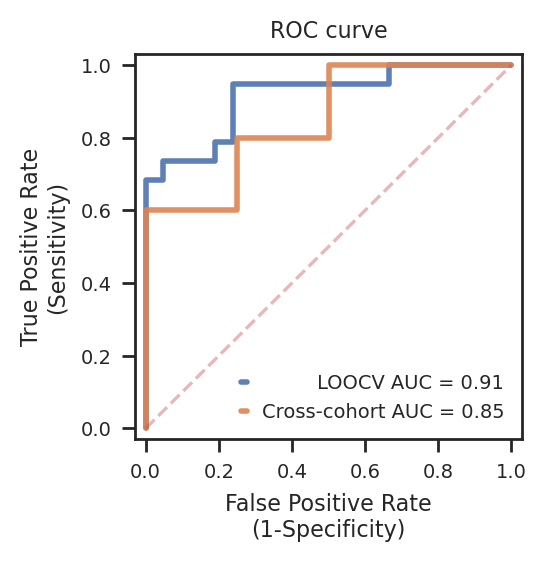

In [68]:
mpl.rcParams["font.family"] = "Arial"
sns.set(context="paper", style="ticks")

f, ax = plt.subplots(figsize=(2.5, 2.5))

fpr, tpr, threshold = metrics.roc_curve(
    [_[0][0] for _ in res[1]], [_[2][0][1] for _ in res[1]]
)
roc_auc = metrics.auc(fpr, tpr)
lw = 2
ax.plot(
    fpr,
    tpr,
    # color=palette[i],
    lw=lw,
    alpha=0.9,
    label="         LOOCV AUC = %0.2f" % (roc_auc),
)

fpr, tpr, threshold = metrics.roc_curve(res[2][0], res[2][2])
roc_auc = metrics.auc(fpr, tpr)

ax.plot(
    fpr,
    tpr,
    # color=palette[i],
    lw=lw,
    alpha=0.9,
    label="Cross-cohort AUC = %0.2f" % (roc_auc),
)

ax.plot([0, 1], [0, 1], "r--", alpha=0.4)
ax.legend(loc="lower right", frameon=False, handlelength=0.3, fontsize=7)
ax.set(
    xlim=[-0.03, 1.03],
    ylim=[-0.03, 1.03],
)
ax.set_title(
    f"ROC curve",
    fontsize=8,
)
ax.set_xlabel(
    "False Positive Rate\n(1-Specificity)",
    fontsize=8,
)
ax.set_ylabel(
    "True Positive Rate\n(Sensitivity)",
    fontsize=8,
)
ax.tick_params(
    axis="both",
    which="major",
    labelsize=7,
)
ax.figure.savefig(
    './Fig.4.png',
    bbox_inches='tight',
    dpi=600)